<a href="https://colab.research.google.com/github/rymadinari/-arene-des-algos-Ryma-Dinari-/blob/main/jour2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# PHASE 0 : Charger le dataset

import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
# PHASE 1 : Audit qualité

def audit_qualite(df):

    print(f"FORME : {df.shape[0]} lignes × {df.shape[1]} colonnes")

    # Types des colonnes
    print("TYPES DES COLONNES :")
    print(df.dtypes.to_string())

    # Pourcentage de manquants par colonne (triés)
    print("MANQUANTS PAR COLONNE (triés) :")
    manquants = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    manquants_affiches = manquants[manquants > 0]
    if len(manquants_affiches) == 0:
        print("  0 manquant détecté (méfiance : des trous peuvent être cachés)")
    else:
        for col, pct in manquants_affiches.items():
            print(f"  {col:<30} {pct:.1f}%")

    # Répartition de la cible Churn
    print("RÉPARTITION DE LA CIBLE (Churn) :")
    if "Churn" not in df.columns:
        print("Colonne Churn absente du dataset")
        return

    total = len(df)
    for val, nb in df["Churn"].value_counts().items():
        pct = nb / total * 100
        print(f"  {val:<5} : {nb:>5} ({pct:.1f}%) ")

    # Alerte déséquilibre
    pct_max = df["Churn"].value_counts(normalize=True).max() * 100
    if pct_max > 65:
        print(f"Déséquilibré ! Classe majoritaire = {pct_max:.1f}%")


audit_qualite(df)

FORME : 7043 lignes × 21 colonnes
TYPES DES COLONNES :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
MANQUANTS PAR COLONNE (triés) :
  0 manquant détecté (méfiance : des trous peuvent être cachés)
RÉPARTITION DE LA CIBLE (Churn) :
  No    :  5174 (73.5%) 
  Yes   :  1869 (26.5%) 
Déséquilibré ! Classe majoritaire = 73.5%


In [44]:
print("Checkpoint 2 : une seule classe")
audit_qualite(df[df["Churn"] == "No"])

print("Checkpoint 3 : déséquilibre visible ?")
audit_qualite(df)

Checkpoint 2 : une seule classe
FORME : 5174 lignes × 21 colonnes
TYPES DES COLONNES :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
MANQUANTS PAR COLONNE (triés) :
  0 manquant détecté (méfiance : des trous peuvent être cachés)
RÉPARTITION DE LA CIBLE (Churn) :
  No    :  5174 (100.0%) 
Déséquilibré ! Classe majoritaire = 100.0%
Checkpoint 3 : déséquilibre visible ?
FORME : 7043 lignes × 21 colonnes
TYPES DES COLONNES :
customerID           object
gende

In [45]:
# PHASE 2 : La colonne piégée — TotalCharges

def reparer_total_charges(df):
    df = df.copy()

    if "TotalCharges" not in df.columns:
        print("Colonne TotalCharges absente")
        return df

    original_dtype = df["TotalCharges"].dtype
    print(f"Type original : {original_dtype}")

    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    nb_nan = df["TotalCharges"].isnull().sum()
    print(f"Trous cachés révélés : {nb_nan} lignes")

    if nb_nan > 0:
        print("Aperçu des lignes problématiques :")
        print(df[df["TotalCharges"].isnull()][
            ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
        ])

        mediane = df["TotalCharges"].median()
        df["TotalCharges"] = df["TotalCharges"].fillna(mediane)
        print(f"Imputé par la médiane : {mediane:.2f}")

    print(f"Type final : {df['TotalCharges'].dtype}")
    return df


df = reparer_total_charges(df)
print("Vérification :", df["TotalCharges"].isnull().sum(), "NaN restants")

Type original : object
Trous cachés révélés : 11 lignes
Aperçu des lignes problématiques :
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN
Imputé par la médiane : 1397.47
Type final : float64
Vérification : 0 NaN restants


In [46]:
# PHASE 3 : Encoder les catégorielles

def encoder_features(df):
    df = df.copy()

    if "customerID" in df.columns:
        nb_clients_uniques = df["customerID"].nunique()
        df = df.drop(columns=["customerID"])
        print(f"customerID supprimé")
        print(f"   Si One-Hot par erreur : {nb_clients_uniques} colonnes créées !")

    df["Churn"] = (df["Churn"] == "Yes").astype(int)
    print("Churn encodé : Yes=1, No=0")

    cols_binaires = [
        col for col in df.columns
        if df[col].dtype == "object"
        and set(df[col].dropna().unique()).issubset({"Yes", "No"})
    ]
    for col in cols_binaires:
        df[col] = (df[col] == "Yes").astype(int)
    print(f"Binaires encodées : {cols_binaires}")

    if "gender" in df.columns:
        df["gender"] = (df["gender"] == "Male").astype(int)
        print(" gender : Male=1, Female=0")

    if "Contract" in df.columns:
        print(" Contract → One-Hot (choix nominal, voir README)")
        print(f"   Modalités : {df['Contract'].unique()}")

    cols_nominales = [col for col in df.columns if df[col].dtype == "object"]
    print(f"\nColonnes nominales restantes → One-Hot : {cols_nominales}")

    for col in cols_nominales:
        counts = df[col].value_counts()
        rares = counts[counts == 1]
        if len(rares) > 0:
            print(f" {col} a {len(rares)} catégorie(s) ultra-rare(s) : {list(rares.index)}")
            print(f"      → créera une colonne One-Hot à 1 seul '1' : bruit pur")

    df = pd.get_dummies(df, columns=cols_nominales, drop_first=False)

    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)

    print(f"Encodage terminé")
    print(f"   Colonnes avant : 21 | Colonnes après : {df.shape[1]}")
    print(f"   Toutes numériques : {all(df.dtypes != 'object')}")

    return df


df_encoded = encoder_features(df)

customerID supprimé
   Si One-Hot par erreur : 7043 colonnes créées !
Churn encodé : Yes=1, No=0
Binaires encodées : ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
 gender : Male=1, Female=0
 Contract → One-Hot (choix nominal, voir README)
   Modalités : ['Month-to-month' 'One year' 'Two year']

Colonnes nominales restantes → One-Hot : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Encodage terminé
   Colonnes avant : 21 | Colonnes après : 41
   Toutes numériques : True


Colonne               Borne basse  Borne haute   Outliers
tenure                     -60.00       124.00          0
MonthlyCharges             -46.02       171.38          0
TotalCharges             -4674.34      8863.16          0


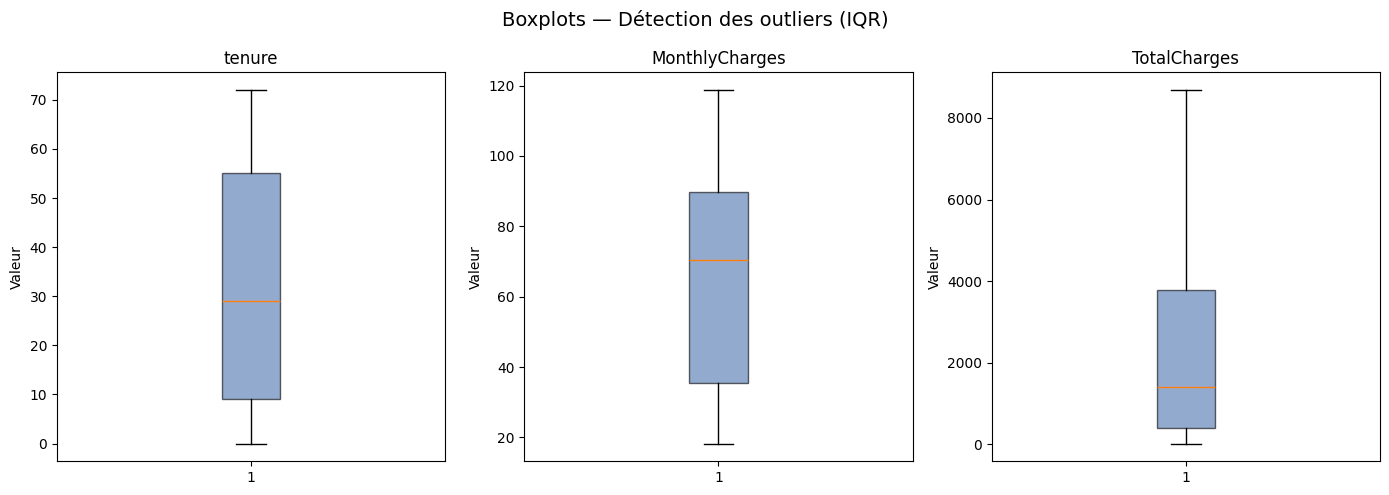


DÉCISION PAR COLONNE :
- tenure        : pas d'outlier on a rien à faire
- MonthlyCharges: outliers plausibles on garde
- TotalCharges  : outliers = anciens clients à fort montant on garde

Justification : dans le churn télécom, un client avec une facture élevée
est un cas réel précieux, pas une erreur de saisie. Supprimer ces lignes
effacerait nos meilleurs (ou pires) clients.

Churners perdus : 0
Soit 0.00% des résiliations


In [47]:
# PHASE 4 : Détecter les outliers (IQR)
import matplotlib.pyplot as plt

def detecter_outliers_iqr(df, colonne):

    if colonne not in df.columns:
        print(f"  Colonne '{colonne}' absente")
        return None, None, 0

    serie = df[colonne].dropna()

    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    nb_outliers = ((serie < borne_basse) | (serie > borne_haute)).sum()

    return borne_basse, borne_haute, nb_outliers


cols_num = ["tenure", "MonthlyCharges", "TotalCharges"]

print("=" * 60)
print(f"{'Colonne':<20} {'Borne basse':>12} {'Borne haute':>12} {'Outliers':>10}")
print("=" * 60)
for col in cols_num:
    bb, bh, nb = detecter_outliers_iqr(df, col)
    print(f"{col:<20} {bb:>12.2f} {bh:>12.2f} {nb:>10}")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, cols_num):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.6))
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Valeur")
plt.suptitle("Boxplots — Détection des outliers (IQR)", fontsize=14)
plt.tight_layout()
plt.savefig("boxplots_outliers.png", dpi=150)
plt.show()

print("""
DÉCISION PAR COLONNE :
- tenure        : pas d'outlier on a rien à faire
- MonthlyCharges: outliers plausibles on garde
- TotalCharges  : outliers = anciens clients à fort montant on garde

Justification : dans le churn télécom, un client avec une facture élevée
est un cas réel précieux, pas une erreur de saisie. Supprimer ces lignes
effacerait nos meilleurs (ou pires) clients.
""")

bb, bh, _ = detecter_outliers_iqr(df, "MonthlyCharges")
masque_outlier = (df["MonthlyCharges"] < bb) | (df["MonthlyCharges"] > bh)
if "Churn" in df.columns:

    if df["Churn"].dtype == "object":
        churners_perdus = (df.loc[masque_outlier, "Churn"] == "Yes").sum()
        total_churners = (df["Churn"] == "Yes").sum()
    else:
        churners_perdus = df.loc[masque_outlier, "Churn"].sum()
        total_churners = df["Churn"].sum()

    pourcentage = (churners_perdus / total_churners) * 100

    print(f"Churners perdus : {churners_perdus}")
    print(f"Soit {pourcentage:.2f}% des résiliations")

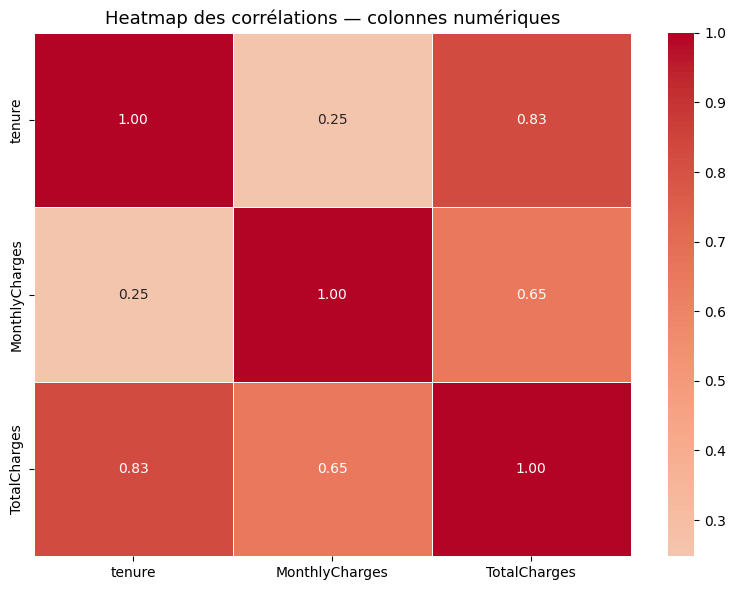


VIF PAR COLONNE (> 5 = problème) :
  tenure               VIF = 6.32 ! 
  MonthlyCharges       VIF = 3.36
  TotalCharges         VIF = 8.07 ! 
→ Colonnes redondantes à envisager de supprimer : ['tenure', 'TotalCharges']

DÉCISION :
On supprime TotalCharges pour éliminer la redondance.

 TotalCharges supprimée
VIF après suppression :


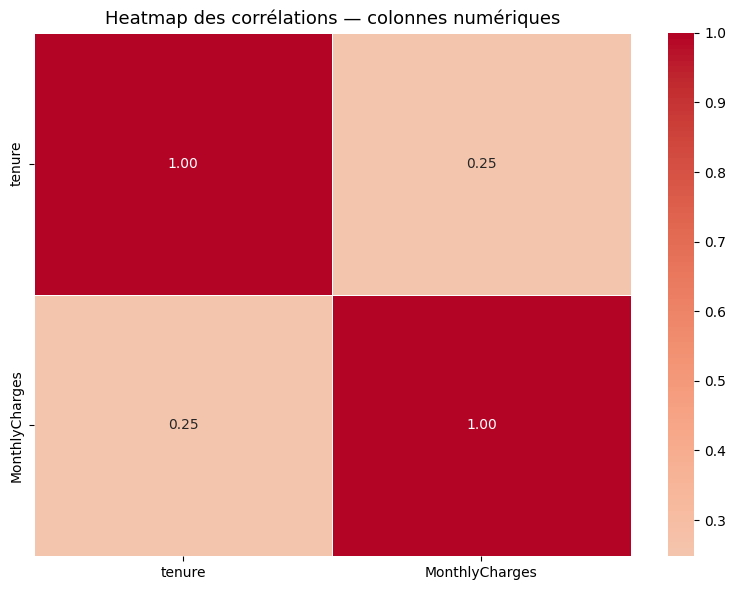


VIF PAR COLONNE (> 5 = problème) :
  tenure               VIF = 2.61
  MonthlyCharges       VIF = 2.61


[('tenure', np.float64(2.612606693233795)),
 ('MonthlyCharges', np.float64(2.6126066932337952))]

In [48]:
# PHASE 5 : Corrélations et multicolinéarité (VIF)

import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

def rapport_multicolinearite(df, colonnes_num):

    corr = df[colonnes_num].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="coolwarm",
        center=0, ax=ax, linewidths=0.5
    )
    ax.set_title("Heatmap des corrélations — colonnes numériques", fontsize=13)
    plt.tight_layout()
    plt.savefig("heatmap_correlations.png", dpi=150)
    plt.show()

    print("VIF PAR COLONNE (> 5 = problème) :")
    X_vif = df[colonnes_num].dropna()

    vif_data = []
    for i, col in enumerate(colonnes_num):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
        except Exception:
            vif = float("inf")
        vif_data.append((col, vif))
        alerte = " ! " if vif > 5 else ""
        print(f"  {col:<20} VIF = {vif:.2f}{alerte}")


    a_supprimer = [col for col, vif in vif_data if vif > 5]
    if a_supprimer:
        print(f"→ Colonnes redondantes à envisager de supprimer : {a_supprimer}")

    return vif_data


cols_num = ["tenure", "MonthlyCharges", "TotalCharges"]
vif_data = rapport_multicolinearite(df_encoded, cols_num)

print("""
DÉCISION :
On supprime TotalCharges pour éliminer la redondance.
""")

df_encoded = df_encoded.drop(columns=["TotalCharges"])
print(" TotalCharges supprimée")

print("VIF après suppression :")
rapport_multicolinearite(df_encoded, ["tenure", "MonthlyCharges"])

Rang   Info Mutuelle                  Random Forest                 
1      Contract_Month-to-month (0.100) tenure (0.211)                
2      tenure (0.073)                 MonthlyCharges (0.207)        
3      TechSupport_No (0.072)         Contract_Month-to-month (0.059)
4      OnlineSecurity_No (0.064)      gender (0.035)                
5      Contract_Two year (0.055)      OnlineSecurity_No (0.034)     
6      InternetService_Fiber optic (0.048) PaymentMethod_Electronic check (0.031)
7      PaymentMethod_Electronic check (0.046) PaperlessBilling (0.029)      
8      MonthlyCharges (0.045)         Partner (0.027)               
9      InternetService_No (0.037)     InternetService_Fiber optic (0.025)
10     DeviceProtection_No (0.036)    TechSupport_No (0.025)        


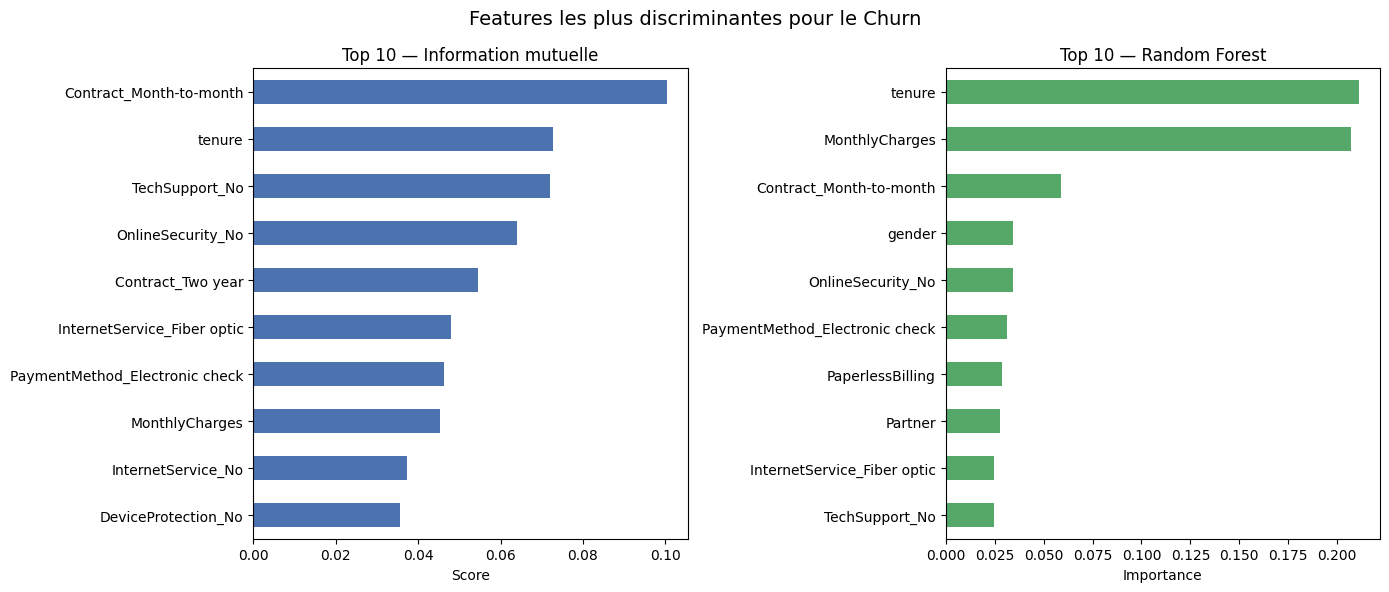

In [49]:
# PHASE 6 : Features discriminantes

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

def features_discriminantes(df, cible="Churn"):

    X = df.drop(columns=[cible])
    y = df[cible]

    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    rf_series = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    top = 10
    print(f"{'Rang':<6} {'Info Mutuelle':<30} {'Random Forest':<30}")
    for i in range(top):
        col_mi = f"{mi_series.index[i]} ({mi_series.iloc[i]:.3f})"
        col_rf = f"{rf_series.index[i]} ({rf_series.iloc[i]:.3f})"
        print(f"{i+1:<6} {col_mi:<30} {col_rf:<30}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    mi_series.head(top).plot(kind="barh", ax=axes[0], color="#4C72B0")
    axes[0].set_title("Top 10 — Information mutuelle", fontsize=12)
    axes[0].set_xlabel("Score")
    axes[0].invert_yaxis()

    rf_series.head(top).plot(kind="barh", ax=axes[1], color="#55A868")
    axes[1].set_title("Top 10 — Random Forest", fontsize=12)
    axes[1].set_xlabel("Importance")
    axes[1].invert_yaxis()

    plt.suptitle("Features les plus discriminantes pour le Churn", fontsize=14)
    plt.tight_layout()
    plt.savefig("features_discriminantes.png", dpi=150)
    plt.show()

    return mi_series, rf_series


mi_scores, rf_scores = features_discriminantes(df_encoded)



In [54]:
# PHASE 7 : Split, scaling, et démo data leakage

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

def split_et_scale_proprement(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
    print(f"Churn dans train : {y_train.mean()*100:.1f}%")
    print(f"Churn dans test  : {y_test.mean()*100:.1f}%")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print("VERSION HONNÊTE — scaler fitté sur train seul")
X_train_h, X_test_h, y_train, y_test, scaler_h = split_et_scale_proprement(X, y)

model_honnete = LogisticRegression(max_iter=1000, random_state=42)
model_honnete.fit(X_train_h, y_train)
acc_h    = accuracy_score(y_test, model_honnete.predict(X_test_h))
recall_h = recall_score(y_test, model_honnete.predict(X_test_h))
print(f"Accuracy : {acc_h*100:.2f}%")
print(f"Recall churners : {recall_h*100:.2f}%")


print("VERSION TRICHÉE — scaler fitté sur TOUT X avant split")

scaler_triche = StandardScaler()
X_all_scaled  = scaler_triche.fit_transform(X)

X_train_t, X_test_t, _, _ = train_test_split(
    X_all_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model_triche = LogisticRegression(max_iter=1000, random_state=42)
model_triche.fit(X_train_t, y_train)
acc_t    = accuracy_score(y_test, model_triche.predict(X_test_t))
recall_t = recall_score(y_test, model_triche.predict(X_test_t))
print(f"Accuracy : {acc_t*100:.2f}%")
print(f"Recall churners : {recall_t*100:.2f}%")


print("VERDICT")
mensonge_acc    = (acc_t - acc_h) * 100
mensonge_recall = (recall_t - recall_h) * 100
print(f"Écart accuracy    : {mensonge_acc:+.2f} pp")
print(f"Écart recall      : {mensonge_recall:+.2f} pp")


df_encoded.to_csv("telco_clean.csv", index=False)
print(" Dataset propre sauvegardé : telco_clean.csv")
print(f" Shape finale : {df_encoded.shape}")

VERSION HONNÊTE — scaler fitté sur train seul
Train : 5634 lignes | Test : 1409 lignes
Churn dans train : 26.5%
Churn dans test  : 26.5%
Accuracy : 79.70%
Recall churners : 55.08%
VERSION TRICHÉE — scaler fitté sur TOUT X avant split
Accuracy : 79.70%
Recall churners : 55.08%
VERDICT
Écart accuracy    : +0.00 pp
Écart recall      : +0.00 pp
 Dataset propre sauvegardé : telco_clean.csv
 Shape finale : (7043, 40)


In [61]:
# PHASE 8:DATACLEANER — classe maison fit/transform

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

class DataCleaner:

    def fit(self, df):
        df = df.copy()

        self.cols_a_jeter_ = [
            col for col in df.columns
            if df[col].dtype == "object" and df[col].nunique() > 50
        ]
        if self.cols_a_jeter_:
            print(f"  Colonnes haute cardinalité ignorées : {self.cols_a_jeter_}")
        df = df.drop(columns=self.cols_a_jeter_, errors="ignore")

        self.medianes_ = df.select_dtypes(include=np.number).median()

        self.categories_ = {}
        for col in df.select_dtypes(include="object").columns:
            self.categories_[col] = list(df[col].dropna().unique())

        self.cols_binaires_ = [
            col for col in df.columns
            if df[col].dtype == "object"
            and set(df[col].dropna().unique()).issubset({"Yes", "No"})
        ]

        self.cols_nominales_ = [
            col for col in df.select_dtypes(include="object").columns
            if col not in self.cols_binaires_
            and col != "Churn"
            and col != "gender"
        ]

        df_sim = self._transformer_interne(df)
        self.colonnes_finales_ = list(df_sim.columns)

        cols_num = df_sim.select_dtypes(include=np.number).columns
        self.scaler_ = StandardScaler()
        self.scaler_.fit(df_sim[cols_num])
        self.cols_num_finales_ = list(cols_num)

        print(f" fit() terminé — {len(self.colonnes_finales_)} colonnes mémorisées")
        return self

    def _transformer_interne(self, df):
        df = df.copy()

        df = df.drop(columns=self.cols_a_jeter_, errors="ignore")

        if "Churn" in df.columns and df["Churn"].dtype == "object":
            df["Churn"] = (df["Churn"] == "Yes").astype(int)

        if "gender" in df.columns and df["gender"].dtype == "object":
            df["gender"] = (df["gender"] == "Male").astype(int)

        for col in self.cols_binaires_:
            if col in df.columns:
                df[col] = (df[col] == "Yes").astype(int)

        for col, med in self.medianes_.items():
            if col in df.columns:
                df[col] = df[col].fillna(med)

        if "TotalCharges" in df.columns and df["TotalCharges"].dtype == "object":
            df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
            df["TotalCharges"] = df["TotalCharges"].fillna(self.medianes_.get("TotalCharges", 0))

        for col in self.cols_nominales_:
            if col not in df.columns:
                continue
            cats = self.categories_.get(col, [])
            for cat in cats:
                df[f"{col}_{cat}"] = (df[col] == cat).astype(int)
            df = df.drop(columns=[col])

        return df

    def transform(self, df):
        df = self._transformer_interne(df)

        for col in self.colonnes_finales_:
            if col not in df.columns:
                df[col] = 0
        df = df[self.colonnes_finales_]

        df[self.cols_num_finales_] = self.scaler_.transform(df[self.cols_num_finales_])

        return df

    def fit_transform(self, df):
        return self.fit(df).transform(df)

In [64]:
# TESTS — les 3 asserts obligatoires

from sklearn.model_selection import train_test_split

df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
X_train_raw, X_test_raw = train_test_split(df_raw, test_size=0.2, random_state=42)

cleaner = DataCleaner()
X_train_clean = cleaner.fit_transform(X_train_raw)
X_test_clean  = cleaner.transform(X_test_raw)


assert X_train_clean.isna().sum().sum() == 0, " Des NaN restants dans le train !"
assert X_test_clean.isna().sum().sum() == 0,  " Des NaN restants dans le test !"
print(" Test 1 passé : zéro trou dans train et test")


une_ligne = X_test_raw.head(1)
result = cleaner.transform(une_ligne)
assert result.shape[0] == 1, " La transformation d'une seule ligne a planté !"
assert list(result.columns) == list(X_train_clean.columns), "Colonnes désalignées sur 1 ligne !"
print(" Test 2 passé : fonctionne sur une seule ligne")


X_test_piege = X_test_raw.copy()
X_test_piege.loc[X_test_piege.index[0], "PaymentMethod"] = "Crypto-monnaie (inventée)"

result_piege = cleaner.transform(X_test_piege)
assert list(result_piege.columns) == list(X_train_clean.columns), \
    " Une catégorie inconnue a créé/supprimé une colonne !"
print(" Test 3 passé : catégorie inconnue ignorée, colonnes stables")

print(f"   Train : {X_train_clean.shape} | Test : {X_test_clean.shape}")

  Colonnes haute cardinalité ignorées : ['customerID', 'TotalCharges']
 fit() terminé — 40 colonnes mémorisées
 Test 1 passé : zéro trou dans train et test
 Test 2 passé : fonctionne sur une seule ligne
 Test 3 passé : catégorie inconnue ignorée, colonnes stables
   Train : (5634, 40) | Test : (1409, 40)
